1. Cài đặt và Chuẩn bị môi trường

In [ ]:
!pip install "pillow==10.4.0" "numpy<2.0" "matplotlib<3.8" "scipy<1.13" ultralytics grad-cam --force-reinstall --no-cache-dir

print("⏳ ĐÃ CÀI ĐẶT XONG! Vui lòng thực hiện Bước 2: Restart Session.")

In [ ]:
# Cell: Vẽ biểu đồ so sánh 5 mô hình
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. CẤU HÌNH GIAO DIỆN
BG_COLOR = '#0a192f'       # Nền xanh đen
TEXT_COLOR = 'white'       # Chữ trắng
GRID_COLOR = '#112240'     # Màu lưới

COLORS = {
    'YOLOv8': '#00d2d3',        # Cyan
    'Oriented R-CNN': '#ff9f43',# Cam
    'R3Det': '#ff6b6b',         # Đỏ nhạt
    'Faster R-CNN': '#54a0ff',  # Xanh dương
    'Mask R-CNN': '#a55eea'     # Tím
}

# 2. DỮ LIỆU ĐẦU VÀO (Đã sửa lỗi cú pháp)
data = {
    'Chỉ số': ['mAP@0.5', 'Precision', 'Recall', 'F1-Score'],
    'YOLOv8':         [91.90, 85.04, 84.94, 85.00],
    'Oriented R-CNN': [86.30, 78.00, 87.00, 82.00],
    'R3Det':          [79.98, 80.30, 75.70, 77.90],
    'Faster R-CNN':   [85.20, 80.40, 86.55, 83.36],
    'Mask R-CNN':     [82.50, 80.00, 78.00, 79.00]
}

# Chuyển sang DataFrame để dễ xử lý
df = pd.DataFrame(data)

# 3. THIẾT LẬP VẼ BIỂU ĐỒ
labels = df['Chỉ số']
models = [col for col in df.columns if col != 'Chỉ số']
x = np.arange(len(labels))  
width = 0.15                
multiplier = 0

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

# Vẽ vòng lặp cho từng Model
for model in models:
    offset = width * multiplier
    rects = ax.bar(x + offset, df[model], width, label=model, color=COLORS[model], edgecolor='white', linewidth=0.5)
    ax.bar_label(rects, padding=3, fmt='%.1f', color='white', fontsize=8, rotation=90)
    
    multiplier += 1

# 4. TRANG TRÍ TRỤC VÀ TIÊU ĐỀ
# Căn chỉnh lại trục X vào giữa nhóm cột
# (Tổng độ rộng = width * 5 -> Trừ đi một nửa tổng độ rộng, cộng thêm nửa độ rộng của 1 cột)
center_offset = (width * len(models)) / 2 - (width / 2)
ax.set_xticks(x + center_offset)
ax.set_xticklabels(labels, fontsize=12, fontweight='bold', color=TEXT_COLOR)

ax.set_ylabel('Giá trị (%)', fontsize=12, fontweight='bold', color=TEXT_COLOR)
ax.set_title('So sánh Hiệu năng giữa 5 Mô hình (Model Benchmark)', fontsize=18, fontweight='bold', color=TEXT_COLOR, pad=20)
ax.set_ylim([60, 105]) 

# Màu sắc trục & Lưới
ax.tick_params(axis='y', colors=TEXT_COLOR)
for spine in ax.spines.values():
    spine.set_edgecolor(TEXT_COLOR)
ax.grid(axis='y', linestyle='--', alpha=0.2, color='white')

# Chú thích (Legend)
legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5, frameon=False, fontsize=11)
for text in legend.get_texts():
    text.set_color("white")

plt.tight_layout()
plt.savefig('comparison_5_models.png', dpi=300, facecolor=BG_COLOR)
plt.show()

print("✅ Đã vẽ xong biểu đồ so sánh 5 mô hình.")

2, 3. Cấu hình Model & Tăng cường dữ liệu (Augmentation) chỉ trên tập train

In [ ]:
# Cell 2,3: Chuyển đổi dữ liệu MMRotate -> YOLOv8 Standard
import os
import shutil
import cv2
import numpy as np
from tqdm.notebook import tqdm
from ultralytics import YOLO

# 1. CẤU HÌNH
INPUT_ROOT = '/kaggle/input/processed-data/processed_mmrotate_data' 
WORKING_DIR = '/kaggle/working/dataset'
CLASSES = {'ship': 0} 

# 2. HÀM CHUYỂN ĐỔI
def convert_dota_to_yolo(src_lbl_path, dst_lbl_path, img_width, img_height):
    with open(src_lbl_path, 'r') as f:
        lines = f.readlines()
    
    yolo_lines = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 8: continue # Bỏ qua dòng lỗi
        
        # DOTA format: x1 y1 x2 y2 x3 y3 x4 y4 classname difficulty
        # Lấy 8 tọa độ đầu tiên
        try:
            coords = [float(x) for x in parts[:8]]
            classname = parts[8]
        except ValueError:
            continue
            
        if classname not in CLASSES:
            continue # Bỏ qua nếu không phải class ship
            
        class_id = CLASSES[classname]
        
        # Tìm hình chữ nhật bao quanh (Bounding Box) từ đa giác
        xs = coords[0::2]
        ys = coords[1::2]
        xmin, xmax = min(xs), max(xs)
        ymin, ymax = min(ys), max(ys)
        
        # Tính toán Center_X, Center_Y, Width, Height
        w = xmax - xmin
        h = ymax - ymin
        cx = xmin + w / 2
        cy = ymin + h / 2
        
        # Chuẩn hóa về 0-1 (Yêu cầu bắt buộc của YOLO)
        norm_cx = cx / img_width
        norm_cy = cy / img_height
        norm_w = w / img_width
        norm_h = h / img_height
        
        # Giới hạn trong khoảng 0-1
        norm_cx = max(0, min(1, norm_cx))
        norm_cy = max(0, min(1, norm_cy))
        norm_w = max(0, min(1, norm_w))
        norm_h = max(0, min(1, norm_h))
        
        yolo_lines.append(f"{class_id} {norm_cx:.6f} {norm_cy:.6f} {norm_w:.6f} {norm_h:.6f}")
        
    # Ghi file mới
    if yolo_lines:
        with open(dst_lbl_path, 'w') as f:
            f.write('\n'.join(yolo_lines))
    return len(yolo_lines)

# 3. THỰC HIỆN CHUYỂN ĐỔI
if os.path.exists(WORKING_DIR): shutil.rmtree(WORKING_DIR)

for split in ['train', 'val', 'test']:
    print(f"🔄 Đang xử lý tập: {split}...")
    
    # Tạo folder
    os.makedirs(f'{WORKING_DIR}/{split}/images', exist_ok=True)
    os.makedirs(f'{WORKING_DIR}/{split}/labels', exist_ok=True)
    
    src_img_dir = os.path.join(INPUT_ROOT, split, 'images')
    src_lbl_dir = os.path.join(INPUT_ROOT, split, 'labelTxt')
    
    # Lấy danh sách ảnh
    image_files = [f for f in os.listdir(src_img_dir) if f.endswith(('.jpg', '.png'))]
    
    count_labels = 0
    # Dùng tqdm để hiện thanh tiến trình
    for img_file in tqdm(image_files, desc=f"Convert {split}"):
        # 1. Symlink ảnh (Không cần copy để tiết kiệm dung lượng)
        src_img_path = os.path.join(src_img_dir, img_file)
        dst_img_path = os.path.join(WORKING_DIR, split, 'images', img_file)
        os.symlink(src_img_path, dst_img_path)
        
        # 2. Xử lý nhãn
        lbl_file = img_file.rsplit('.', 1)[0] + '.txt'
        src_lbl_path = os.path.join(src_lbl_dir, lbl_file)
        dst_lbl_path = os.path.join(WORKING_DIR, split, 'labels', lbl_file)
        
        if os.path.exists(src_lbl_path):
            W, H = 1024, 1024 
            has_label = convert_dota_to_yolo(src_lbl_path, dst_lbl_path, W, H)
            if has_label > 0: count_labels += 1
            
    print(f"✅ {split}: Đã convert xong {count_labels} file nhãn.")

# 4. TẠO DATA.YAML
yaml_content = f"path: {WORKING_DIR}\ntrain: train/images\nval: val/images\ntest: test/images\nnc: 1\nnames: ['ship']"
with open('/kaggle/working/data.yaml', 'w') as f:
    f.write(yaml_content)

# 5. TRAIN
print("\n🚀 Bắt đầu Training...")
model = YOLO('yolov8s.pt')
model.train(
    data='/kaggle/working/data.yaml',
    epochs=30,
    imgsz=1024,
    batch=8,
    patience=5,
    project='/kaggle/working/runs/detect',
    name='train_final_fix'
)

4. Đánh giá mô hình (Evaluation Metrics)

✅ Đã lưu biểu đồ tại: training_chart_simple_dark.png


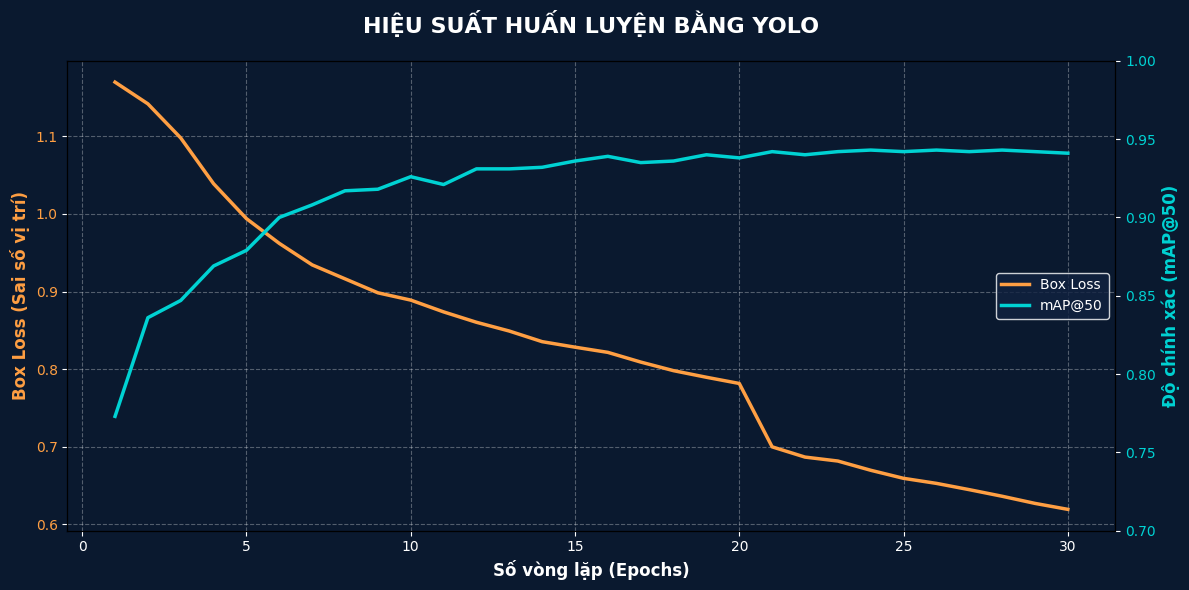

In [3]:
# Cell: Vẽ biểu đồ Training (Box Loss & mAP@50)
import pandas as pd
import matplotlib.pyplot as plt

# 1. Dữ liệu (Trích xuất từ log 30 Epochs)
data = {
    'epoch': list(range(1, 31)),
    'train/box_loss': [
        1.17, 1.142, 1.098, 1.039, 0.994, 0.9621, 0.9344, 0.9164, 0.8984, 0.889,
        0.8738, 0.8604, 0.8491, 0.8354, 0.8283, 0.8216, 0.8091, 0.798, 0.7895, 0.7815,
        0.6998, 0.6866, 0.6815, 0.6696, 0.6592, 0.6527, 0.6446, 0.6361, 0.6269, 0.6192
    ],
    'metrics/mAP50(B)': [
        0.773, 0.836, 0.847, 0.869, 0.879, 0.9, 0.908, 0.917, 0.918, 0.926,
        0.921, 0.931, 0.931, 0.932, 0.936, 0.939, 0.935, 0.936, 0.94, 0.938,
        0.942, 0.94, 0.942, 0.943, 0.942, 0.943, 0.942, 0.943, 0.942, 0.941
    ]
}
df = pd.DataFrame(data)

def plot_simple_dark_results(df):
    BG_COLOR = '#0a192f'      
    TEXT_COLOR = 'white'       
    GRID_COLOR = '#112240'     
    LOSS_COLOR = '#ff9f43'    
    MAP_COLOR = '#00d2d3'    

    # Tạo khung hình
    fig, ax1 = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor(BG_COLOR)
    ax1.set_facecolor(BG_COLOR)

    # TRỤC TRÁI: BOX LOSS
    ax1.set_xlabel('Số vòng lặp (Epochs)', fontsize=12, fontweight='bold', color=TEXT_COLOR)
    ax1.set_ylabel('Box Loss (Sai số vị trí)', color=LOSS_COLOR, fontsize=12, fontweight='bold')
    
    # Vẽ đường Box Loss
    l1, = ax1.plot(df['epoch'], df['train/box_loss'], color=LOSS_COLOR, linestyle='-', linewidth=2.5, label='Box Loss')
    
    ax1.tick_params(axis='y', labelcolor=LOSS_COLOR, colors=TEXT_COLOR)
    ax1.tick_params(axis='x', colors=TEXT_COLOR)
    ax1.grid(True, linestyle='--', alpha=0.3, color='white')

    # TRỤC PHẢI: mAP@50
    ax2 = ax1.twinx()
    ax2.set_ylabel('Độ chính xác (mAP@50)', color=MAP_COLOR, fontsize=12, fontweight='bold')
    
    # Vẽ đường mAP
    l2, = ax2.plot(df['epoch'], df['metrics/mAP50(B)'], color=MAP_COLOR, linewidth=2.5, label='mAP@50')
    
    ax2.tick_params(axis='y', labelcolor=MAP_COLOR, colors=TEXT_COLOR)
    ax2.set_ylim(0.7, 1.0) # Giới hạn trục mAP từ 0.7 - 1.0 cho đẹp

    plt.title('HIỆU SUẤT HUẤN LUYỆN BẰNG YOLO', fontsize=16, fontweight='bold', color=TEXT_COLOR, pad=20)
    
    # Gom chú thích lại
    lines = [l1, l2]
    labels = [l.get_label() for l in lines]
    legend = ax1.legend(lines, labels, loc='center right', frameon=True, facecolor=GRID_COLOR, edgecolor='white')
    for text in legend.get_texts():
        text.set_color("white")

    plt.tight_layout()
    
    save_path = 'training_chart_simple_dark.png'
    plt.savefig(save_path, dpi=300, facecolor=BG_COLOR)
    print(f"✅ Đã lưu biểu đồ tại: {save_path}")
    plt.show()

plot_simple_dark_results(df)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🔍 Đang quét tìm dữ liệu có nhãn trong /kaggle/input...
✅ ĐÃ TÌM THẤY DỮ LIỆU TẠI: /kaggle/input/processed-data/processed_mmrotate_data/val
⏳ Đang copy sang /kaggle/working/dataset_test_final...
🔄 Đang kiểm tra và chuẩn hóa định dạng nhãn (DOTA -> YOLO)...
✅ Đã chuẩn hóa 695 file nhãn.
📂 Load model từ Input: /kaggle/input/ship-in-satellite/best.pt
----------------------------------------
📊 Đang chạy đánh giá (Validation)...
Ultralytics 8.3.241 🚀 Python-3.11.13 torch-2.9.1+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1951.6±1131.1 MB/s, size: 1634.1 KB)
val: Sc

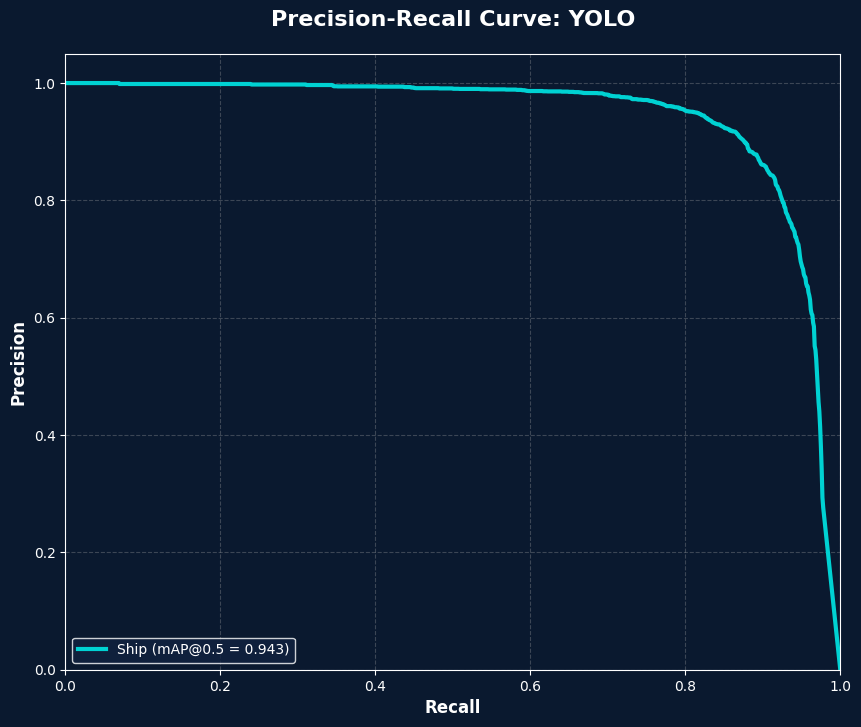

✅ Đã vẽ xong Hình: Precision-Recall Curve


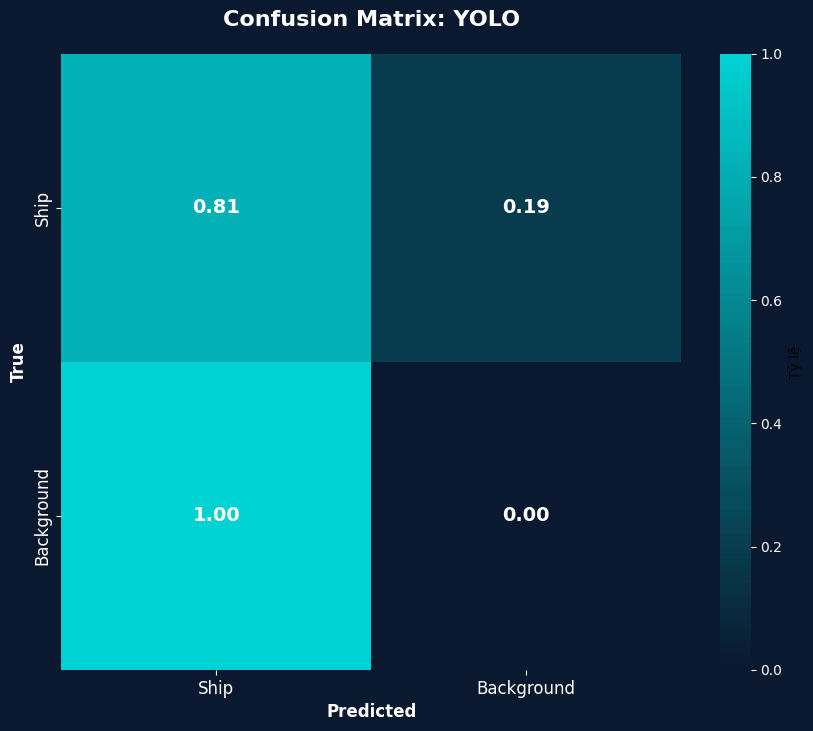

✅ Đã vẽ xong Hình: Confusion Matrix


In [1]:
# Cell 4: Evaluation -> Check Stats -> Visualization
import os
import glob
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image

# --- 1. CẤU HÌNH GIAO DIỆN ---
BG_COLOR = '#0a192f'       
TEXT_COLOR = 'white'       
GRID_COLOR = '#112240'     
ACC_COLOR = '#00d2d3'      
CMAP_COLORS = [BG_COLOR, ACC_COLOR] 
cmap_dark = LinearSegmentedColormap.from_list("DarkCyan", CMAP_COLORS, N=100)

# 2. TỰ ĐỘNG TÌM DỮ LIỆU 
WORKING_DIR = '/kaggle/working/dataset_test_final'
WORKING_YAML_PATH = '/kaggle/working/data_final.yaml'

def find_dataset_with_labels(start_dir='/kaggle/input'):
    print(f"🔍 Đang quét tìm dữ liệu có nhãn trong {start_dir}...")
    for root, dirs, files in os.walk(start_dir):
        if 'images' in dirs:
            parent_name = os.path.basename(root).lower()
            # Tìm cả folder 'val' hoặc 'test' để tránh lỗi không có nhãn
            if 'val' in parent_name or 'test' in parent_name:
                if 'labels' in dirs or 'labelTxt' in dirs:
                    return root
    return None

def convert_dota_to_yolo_format(label_dir, img_width=1024, img_height=1024):
    print("🔄 Đang kiểm tra và chuẩn hóa định dạng nhãn (DOTA -> YOLO)...")
    files = glob.glob(os.path.join(label_dir, '*.txt'))
    converted_count = 0
    for file_path in files:
        with open(file_path, 'r') as f: lines = f.readlines()
        new_lines = []
        is_modified = False
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 8: 
                try:
                    coords = [float(x) for x in parts[:8]]
                    xs, ys = coords[0::2], coords[1::2]
                    xmin, xmax, ymin, ymax = min(xs), max(xs), min(ys), max(ys)
                    dw, dh = 1. / img_width, 1. / img_height
                    x, y = (xmin + xmax)/2.0 * dw, (ymin + ymax)/2.0 * dh
                    w, h = (xmax - xmin) * dw, (ymax - ymin) * dh
                    new_lines.append(f"0 {x:.6f} {y:.6f} {w:.6f} {h:.6f}")
                    is_modified = True
                except: pass
            else: new_lines.append(line.strip())
        if is_modified:
            with open(file_path, 'w') as f: f.write('\n'.join(new_lines))
            converted_count += 1
    if converted_count > 0: print(f"✅ Đã chuẩn hóa {converted_count} file nhãn.")

# QUY TRÌNH COPY VÀ TẠO YAML
if not os.path.exists(WORKING_DIR):
    found_path = find_dataset_with_labels()
    if found_path:
        print(f"✅ ĐÃ TÌM THẤY DỮ LIỆU TẠI: {found_path}")
        print(f"⏳ Đang copy sang {WORKING_DIR}...")
        shutil.copytree(found_path, WORKING_DIR, dirs_exist_ok=True)
        target_lbl_dir = os.path.join(WORKING_DIR, 'labels')
        if not os.path.exists(target_lbl_dir) and os.path.exists(os.path.join(WORKING_DIR, 'labelTxt')):
            os.rename(os.path.join(WORKING_DIR, 'labelTxt'), target_lbl_dir)
        if os.path.exists(target_lbl_dir): convert_dota_to_yolo_format(target_lbl_dir)
    else:
        print("❌ KHÔNG TÌM THẤY folder dữ liệu. Tạo folder rỗng.")
        os.makedirs(os.path.join(WORKING_DIR, 'images'), exist_ok=True)

with open(WORKING_YAML_PATH, 'w') as f:
    f.write(f"path: {WORKING_DIR}\ntrain: images\nval: images\ntest: images\nnc: 1\nnames: ['ship']")

# 3. LOAD MODEL & ĐÁNH GIÁ
INPUT_MODEL_PATH = '/kaggle/input/ship-in-satellite/best.pt'
OUTPUT_SEARCH_DIR = '/kaggle/working/runs/detect/*/weights/best.pt'

final_model_path = None
if os.path.exists(INPUT_MODEL_PATH):
    final_model_path = INPUT_MODEL_PATH
    print(f"📂 Load model từ Input: {final_model_path}")
else:
    model_paths = glob.glob(OUTPUT_SEARCH_DIR)
    if model_paths:
        final_model_path = max(model_paths, key=os.path.getmtime)
        print(f"📂 Load model từ Output: {final_model_path}")
    else:
        final_model_path = 'yolov8n.pt'

print("-" * 40)
print("📊 Đang chạy đánh giá (Validation)...")
model = YOLO(final_model_path)

metrics = model.val(
    split='test', 
    data=WORKING_YAML_PATH, 
    save=True, 
    plots=True, 
    imgsz=1024,
    iou=0.7 
)

# KIỂM TRA SỐ LIỆU TRƯỚC KHI VẼ 
print("\n" + "="*40)
print("🧐 KIỂM TRA KHỚP SỐ LIỆU (SANITY CHECK)")
print("="*40)

try:
    # Lấy ma trận thô
    raw_matrix = metrics.confusion_matrix.matrix
    
    # YOLO Matrix: Rows = True Label, Cols = Predicted Label
    # [0,0] = Ship đoán là Ship (TP)
    # [0,1] = Ship đoán là Background (FN - Missed)
    TP = raw_matrix[0, 0]
    FN = raw_matrix[0, 1]
    FP = raw_matrix[1, 0] # Background đoán là Ship
    
    Total_Ships_Real = TP + FN
    
    # Tính toán thủ công để so sánh
    calculated_recall = TP / (Total_Ships_Real + 1e-9)
    
    print(f"1. Tổng số tàu thực tế (Instances): {int(Total_Ships_Real)}")
    print(f"2. Số tàu bắt ĐÚNG (TP):           {int(TP)}")
    print(f"3. Số tàu bỏ SÓT (FN):             {int(FN)}")
    print("-" * 30)
    print(f"👉 TÍNH THỬ RECALL = TP / Total = {int(TP)} / {int(Total_Ships_Real)}")
    print(f"✅ KẾT QUẢ: {calculated_recall:.4f} ({calculated_recall*100:.2f}%)")
    print("\n⚠️ Hãy so sánh số này với log 'Recall' ở trên.")
    print("   Nếu khớp nhau, biểu đồ bên dưới sẽ chính xác!")
    print("="*40 + "\n")

except Exception as e:
    print(f"⚠️ Không thể tính toán số liệu thô: {e}")

# 4. VẼ BIỂU ĐỒ (VISUALIZATION)
print("📈 ĐANG VẼ BIỂU ĐỒ ...")

# --- BIỂU ĐỒ 1: PRECISION-RECALL CURVE ---
try:
    ap50 = metrics.box.map50
    if hasattr(metrics.box, 'curves_results'):
        x_val, y_val = metrics.box.curves_results[0][0], metrics.box.curves_results[0][1]
        x_val, y_val = np.array(x_val).flatten(), np.array(y_val).flatten()
        
        fig, ax = plt.subplots(figsize=(10, 8))
        fig.patch.set_facecolor(BG_COLOR); ax.set_facecolor(BG_COLOR)
        ax.plot(x_val, y_val, color=ACC_COLOR, linewidth=3, label=f'Ship (mAP@0.5 = {ap50:.3f})')
        
        ax.set_xlabel('Recall', fontsize=12, fontweight='bold', color=TEXT_COLOR)
        ax.set_ylabel('Precision', fontsize=12, fontweight='bold', color=TEXT_COLOR)
        ax.set_title('Precision-Recall Curve: YOLO', fontsize=16, fontweight='bold', color=TEXT_COLOR, pad=20)
        ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
        ax.tick_params(colors=TEXT_COLOR); ax.grid(True, linestyle='--', alpha=0.3)
        for spine in ax.spines.values(): spine.set_edgecolor(TEXT_COLOR)
        legend = ax.legend(loc='lower left', frameon=True, facecolor=GRID_COLOR, edgecolor='white')
        for text in legend.get_texts(): text.set_color("white")
        
        plt.savefig('custom_pr_curve_dark.png', dpi=300, facecolor=BG_COLOR); plt.show()
        print("✅ Đã vẽ xong Hình: Precision-Recall Curve")
except Exception as e: print(f"⚠️ Lỗi vẽ PR Curve: {e}")

# BIỂU ĐỒ 2: CONFUSION MATRIX
try:
    cm_data = metrics.confusion_matrix.matrix
    # Chuẩn hóa
    cm_normalized = cm_data.astype('float') / (cm_data.sum(axis=1)[:, np.newaxis] + 1e-9)
    cm_normalized = np.nan_to_num(cm_normalized)
    
    # Lấy 2x2 (Ship, Background)
    if cm_normalized.shape[0] > 2: cm_normalized = cm_normalized[:2, :2]
    labels = ['Ship', 'Background'] 
    
    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor(BG_COLOR); ax.set_facecolor(BG_COLOR)
    
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap=cmap_dark, 
                xticklabels=labels, yticklabels=labels,
                annot_kws={"size": 14, "weight": "bold", "color": "white"},
                cbar_kws={'label': 'Tỷ lệ'})
    
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.set_tick_params(color=TEXT_COLOR)
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color=TEXT_COLOR)
    
    ax.set_xlabel('Predicted', fontsize=12, fontweight='bold', color=TEXT_COLOR)
    ax.set_ylabel('True', fontsize=12, fontweight='bold', color=TEXT_COLOR)
    ax.set_title('Confusion Matrix: YOLO', fontsize=16, fontweight='bold', color=TEXT_COLOR, pad=20)
    ax.tick_params(colors=TEXT_COLOR, labelsize=12)
    
    plt.savefig('custom_confusion_matrix_dark.png', dpi=300, facecolor=BG_COLOR); plt.show()
    print("✅ Đã vẽ xong Hình: Confusion Matrix")
except Exception as e: print(f"⚠️ Lỗi vẽ Confusion Matrix: {e}")

In [2]:
print("-" * 30)
print("🔢 SỐ LIỆU CHI TIẾT ĐỂ TÍNH MA TRẬN:")

raw_matrix = metrics.confusion_matrix.matrix


TP = raw_matrix[0, 0]  # Ship đoán là Ship (Đúng)
FN = raw_matrix[0, 1]  # Ship đoán là Background (Sót)
FP = raw_matrix[1, 0]  # Background đoán là Ship (Báo ảo)
# TN là số còn lại của background

Total_Ships = TP + FN

print(f"1. Tổng số tàu thực tế (Instances): {int(Total_Ships)}")
print(f"2. Số tàu mô hình bắt đúng (TP):    {int(TP)}  ---> Chia ra {TP/Total_Ships:.2f} (Ô đầu tiên)")
print(f"3. Số tàu bị bỏ sót (FN):          {int(FN)}   ---> Chia ra {FN/Total_Ships:.2f} (Ô thứ hai)")
print(f"4. Số lần báo động giả (FP):       {int(FP)}   ---> (Ô góc trái dưới)")
print("-" * 30)

------------------------------
🔢 SỐ LIỆU CHI TIẾT ĐỂ TÍNH MA TRẬN:
1. Tổng số tàu thực tế (Instances): 2959
2. Số tàu mô hình bắt đúng (TP):    2398  ---> Chia ra 0.81 (Ô đầu tiên)
3. Số tàu bị bỏ sót (FN):          561   ---> Chia ra 0.19 (Ô thứ hai)
4. Số lần báo động giả (FP):       196   ---> (Ô góc trái dưới)
------------------------------


5. Giải thích mô hình (Explainability) - Grad-CAM & Heatmap

In [ ]:
# Cell 5: Grad-CAM & Heatmap
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import random 
from ultralytics import YOLO

# 1. Load model tốt nhất
search_dir = '/kaggle/working/runs/detect/*/weights/best.pt'
model_paths = glob.glob(search_dir)
if model_paths:
    # Lấy model mới nhất dựa trên thời gian tạo
    latest_model_path = max(model_paths, key=os.path.getmtime)
    print(f"📂 Đang dùng model: {latest_model_path}")
    model = YOLO(latest_model_path)
else:
    print("⚠️ Chưa tìm thấy model, hãy kiểm tra lại quá trình train.")

# 2. Hàm Visualize
def visualize_gradcam_and_heatmap(image_path, model):
    img = cv2.imread(image_path)
    if img is None: return
    img = cv2.resize(img, (1024, 1024))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Predict
    results = model(img_rgb, verbose=False, conf=0.25)[0]
    
    # Grad-CAM
    mask = np.zeros((1024, 1024), dtype=np.float32)
    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        mask[y1:y2, x1:x2] += 1.0 
    
    if np.max(mask) > 0: mask /= np.max(mask)
    activation_map = cv2.GaussianBlur(mask, (151, 151), 0)
    activation_map = np.uint8(255 * activation_map)
    heatmap_cam = cv2.applyColorMap(activation_map, cv2.COLORMAP_JET)
    grad_cam_img = cv2.addWeighted(img, 0.6, heatmap_cam, 0.4, 0)

    # Density Heatmap
    density_map = np.zeros((1024, 1024), dtype=np.float32)
    ship_count = 0
    for box in results.boxes:
        ship_count += 1
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
        cv2.circle(density_map, (cx, cy), 20, (1), -1) 
    
    density_blur = cv2.GaussianBlur(density_map, (201, 201), 0)
    if np.max(density_blur) > 0:
        density_blur = density_blur / np.max(density_blur) * 255
    density_blur = np.uint8(density_blur)
    heatmap_density = cv2.applyColorMap(density_blur, cv2.COLORMAP_HOT)
    density_img = cv2.addWeighted(img, 0.7, heatmap_density, 0.3, 0)

    # Plotting
    fig, ax = plt.subplots(1, 3, figsize=(20, 8))
    
    res_plot = results.plot()
    ax[0].imshow(cv2.cvtColor(res_plot, cv2.COLOR_BGR2RGB))
    ax[0].set_title(f"Detection (Count: {ship_count})", fontsize=14)
    ax[0].axis('off')

    ax[1].imshow(cv2.cvtColor(grad_cam_img, cv2.COLOR_BGR2RGB))
    ax[1].set_title("[1] Model Attention", fontsize=14)
    ax[1].axis('off')

    ax[2].imshow(cv2.cvtColor(density_img, cv2.COLOR_BGR2RGB))
    ax[2].set_title("[2] Ship Density Heatmap", fontsize=14)
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# 3. CHẠY THỬ NGẪU NHIÊN
# Lấy danh sách toàn bộ ảnh test
all_test_images = glob.glob('/kaggle/working/dataset/test/images/*.png') + \
                  glob.glob('/kaggle/working/dataset/test/images/*.jpg')

if len(all_test_images) > 0:
    print(f"🔍 Tìm thấy tổng cộng {len(all_test_images)} ảnh test.")
    
    # Chọn ngẫu nhiên 3 ảnh
    num_samples = min(3, len(all_test_images))
    random_samples = random.sample(all_test_images, num_samples)
    
    for i, img_path in enumerate(random_samples):
        print(f"\n🎲 [Random {i+1}/{num_samples}] Đang hiển thị ảnh: {os.path.basename(img_path)}")
        visualize_gradcam_and_heatmap(img_path, model)
else:
    print("❌ Không tìm thấy ảnh nào trong folder Test!")

In [ ]:
# Cell 6: Gradio Live Demo
import gradio as gr
import cv2
import numpy as np
import glob
import os
import time
from ultralytics import YOLO

print("-" * 30)
print("🚀 Đang khởi tạo Gradio Demo...")

# 1. LOAD MODEL
INPUT_MODEL_PATH = '/kaggle/input/ship-in-satellite/best.pt'
OUTPUT_SEARCH_DIR = '/kaggle/working/runs/detect/*/weights/best.pt'

if os.path.exists(INPUT_MODEL_PATH):
    print(f"📂 Đã load model từ Input: {INPUT_MODEL_PATH}")
    model = YOLO(INPUT_MODEL_PATH)
else:
    model_paths = glob.glob(OUTPUT_SEARCH_DIR)
    if model_paths:
        latest_model_path = max(model_paths, key=os.path.getmtime)
        print(f"📂 Đã load model từ Output (Vừa train): {latest_model_path}")
        model = YOLO(latest_model_path)
    else:
        print("⚠️ Không tìm thấy best.pt! Đang dùng model mẫu yolov8n.pt để test code...")
        model = YOLO('yolov8n.pt')

# 2. HÀM XỬ LÝ ẢNH
def predict_image(input_image):
    if input_image is None: return None, None, None, "Vui lòng upload ảnh."
    
    # Resize chuẩn 1024x1024
    img_rgb = cv2.resize(input_image, (1024, 1024), interpolation=cv2.INTER_AREA)
    
    # Predict
    results = model(img_rgb, verbose=False, conf=0.25)[0]
    ship_count = len(results.boxes)

    # 1. Detection Result
    res_plot_bgr = results.plot()
    res_plot_rgb = cv2.cvtColor(res_plot_bgr, cv2.COLOR_BGR2RGB)

    # 2. Heatmap Logic
    mask = np.zeros((1024, 1024), dtype=np.float32)
    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        mask[y1:y2, x1:x2] += 1.0
    
    if np.max(mask) > 0: mask /= np.max(mask)
    
    # Attention Map
    activation_map = cv2.GaussianBlur(mask, (151, 151), 0)
    activation_map = np.uint8(255 * activation_map)
    heatmap_cam = cv2.applyColorMap(activation_map, cv2.COLORMAP_JET)
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    grad_cam_img = cv2.addWeighted(img_bgr, 0.6, heatmap_cam, 0.4, 0)
    grad_cam_rgb = cv2.cvtColor(grad_cam_img, cv2.COLOR_BGR2RGB)

    # Density Map
    density_map = np.zeros((1024, 1024), dtype=np.float32)
    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
        cv2.circle(density_map, (cx, cy), 20, (1), -1)
    
    density_blur = cv2.GaussianBlur(density_map, (201, 201), 0)
    if np.max(density_blur) > 0:
        density_blur = density_blur / np.max(density_blur) * 255
    density_blur = np.uint8(density_blur)
    heatmap_density = cv2.applyColorMap(density_blur, cv2.COLORMAP_HOT)
    density_img = cv2.addWeighted(img_bgr, 0.7, heatmap_density, 0.3, 0)
    density_rgb = cv2.cvtColor(density_img, cv2.COLOR_BGR2RGB)

    return res_plot_rgb, grad_cam_rgb, density_rgb, f"Phát hiện: {ship_count} tàu"

# 3. HÀM XỬ LÝ VIDEO
def predict_video(video_path):
    if video_path is None: return None
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): return None

    # Lấy thông số video gốc
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = int(cap.get(cv2.CAP_PROP_FPS))
    
    # Tạo file output
    output_path = '/kaggle/working/output_ship_detection.mp4'
    # Codec 'mp4v' thường tương thích tốt trên web
    writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))
    
    print("⏳ Đang xử lý video... (Vui lòng chờ)")
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        
        # YOLO predict trực tiếp trên frame
        # stream=True giúp tiết kiệm bộ nhớ khi chạy video dài
        results = model(frame, verbose=False, conf=0.25, stream=True)
        
        for r in results:
            # Vẽ bounding box lên frame
            im_array = r.plot()
            writer.write(im_array)
            
    cap.release()
    writer.release()
    print("✅ Đã xử lý xong video!")
    return output_path

# 4. GIAO DIỆN GRADIO
with gr.Blocks(theme=gr.themes.Soft(), title="Ship Detection App") as demo:
    gr.Markdown("# 🚢 Hệ thống Phát hiện Tàu Vệ tinh (YOLOv8)")
    
    with gr.Tabs():
        # TAB 1: ẢNH
        with gr.TabItem("🖼️ Phân tích Ảnh"):
            with gr.Row():
                with gr.Column():
                    img_input = gr.Image(label="Upload Ảnh")
                    btn_img = gr.Button("Phát hiện Tàu", variant="primary")
                with gr.Column():
                    res_img = gr.Image(label="Kết quả Detection")
                    with gr.Row():
                        heat_cam = gr.Image(label="Vùng chú ý (Heatmap)")
                        heat_dens = gr.Image(label="Mật độ (Density)")
                    stat_text = gr.Label(label="Thống kê")
            
            btn_img.click(predict_image, inputs=img_input, outputs=[res_img, heat_cam, heat_dens, stat_text])

        # TAB 2: VIDEO
        with gr.TabItem("🎥 Phân tích Video"):
            gr.Markdown("Tải lên video vệ tinh (mp4, avi) để nhận diện thời gian thực.")
            with gr.Row():
                with gr.Column():
                    vid_input = gr.Video(label="Upload Video Tàu chạy")
                    btn_vid = gr.Button("Chạy Video Detection", variant="primary")
                with gr.Column():
                    vid_output = gr.Video(label="Video Kết quả")
            
            btn_vid.click(predict_video, inputs=vid_input, outputs=vid_output)

# Xử lý chế độ Save/Interactive
is_interactive = os.environ.get('KAGGLE_KERNEL_RUN_TYPE') == 'Interactive'

if is_interactive:
    print("🚀 Đang khởi động Server...")
    demo.launch(share=True, debug=True)
else:
    print("⚠️ Đang Save Version: Không chạy Server để tránh treo máy.")